# **Import dữ liệu**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
%cd /content/drive/MyDrive/DATASET

/content/drive/MyDrive/DATASET


In [7]:
# Cell 1: Kết nối & Query dữ liệu dựa trên Index cung cấp
import pyodbc
import pandas as pd

# 1. Thiết lập thông tin kết nối (Vẫn giữ nguyên)
conn_string = (
    'DRIVER={SQL Server};'
    'SERVER=localhost\\SQLSERVERDEV;'      # TODO: sửa
    'DATABASE=Final_OLAP;'  # TODO: sửa
    'Trusted_Connection=yes;'
)

try:
    conn = pyodbc.connect(conn_string)
    print("Kết nối thành công đến cơ sở dữ liệu.")

    # 2. Xây dựng SQL Query được điều chỉnh
    # Giả định bảng Fact trung tâm là 'Fact_AdEvents' (vì có nhiều thông tin event/user)
    sql_query_refined = """
    SELECT
        -- Từ Dim_Campaigns
        c.campaign_id,
        c.name,
        c.start_date,
        c.end_date,
        c.duration_days,  -- Cột tính toán trong Dim hoặc Fact
        c.total_budget,
        
        -- Từ Dim_Ads
        a.ad_id,
        a.ad_platform,
        a.ad_type,
        a.target_gender,
        a.target_age_group,
        a.target_interests,
        
        -- Từ Dim_Time
        t.timestamp,
        t.day_of_week,
        t.time_of_day,
        t.month,
        t.year,
        t.is_weekend,
        t.day_of_month,
        t.hour,
        t.minute,
        t.second,
        
        -- Từ Dim_Events
        e.event_id,
        e.event_type,      
        
        -- Từ Dim_Users
        u.user_id,
        u.user_gender,
        u.user_age,
        u.age_group,
        u.country,
        u.location,
        u.interests
        
    FROM Fact_Events AS f 
    
    -- Kết nối với các bảng Dimension
    LEFT JOIN Dim_Campaigns AS c ON f.campaign_id  = c.campaign_id
    LEFT JOIN Dim_Ads       AS a ON f.ad_id        = a.ad_id
    LEFT JOIN Dim_Time      AS t ON f.timestamp      = t.timestamp
    LEFT JOIN Dim_Users     AS u ON f.user_id      = u.user_id 
    LEFT JOIN Dim_Events     AS e ON f.event_id     = e.event_id 
    
    
    """

    # 3. Thực thi Query và đọc dữ liệu vào DataFrame
    df_ads = pd.read_sql(sql_query_refined, conn)
    print("\nTruy vấn dữ liệu thành công với cấu trúc cột mới.")
    print(df_ads.head())

except pyodbc.Error as ex:
    sqlstate = ex.args[0]
    print(f"\nLỗi kết nối hoặc truy vấn: {sqlstate}")
    print(ex)

finally:
    # 4. Đóng kết nối
    if 'conn' in locals() and conn:
        conn.close()
        print("\nĐã đóng kết nối.")

Kết nối thành công đến cơ sở dữ liệu.


C:\Users\Windows\AppData\Local\Temp\ipykernel_18780\1334887153.py:75: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_ads = pd.read_sql(sql_query_refined, conn)



Truy vấn dữ liệu thành công với cấu trúc cột mới.
  campaign_id               name  start_date    end_date duration_days  \
0           1  Campaign_1_Launch  2025-05-25  2025-07-23            59   
1           1  Campaign_1_Launch  2025-05-25  2025-07-23            59   
2           1  Campaign_1_Launch  2025-05-25  2025-07-23            59   
3           1  Campaign_1_Launch  2025-05-25  2025-07-23            59   
4           1  Campaign_1_Launch  2025-05-25  2025-07-23            59   

  total_budget ad_id ad_platform  ad_type target_gender  ... second event_id  \
0     24021.32    56   Instagram  Stories        Female  ...     52      127   
1     24021.32    56   Instagram  Stories        Female  ...     34      246   
2     24021.32    56   Instagram  Stories        Female  ...      0      670   
3     24021.32    56   Instagram  Stories        Female  ...     44      837   
4     24021.32    56   Instagram  Stories        Female  ...      8      855   

   event_type user_id u

In [8]:
df_ads

,campaign_id,name,start_date,end_date,duration_days,total_budget,ad_id,ad_platform,ad_type,target_gender,...,second,event_id,event_type,user_id,user_gender,user_age,age_group,country,location,interests
0,1,Campaign_1_Launch,2025-05-25,2025-07-23,59,24021.32,56,Instagram,Stories,Female,...,52,127,Impression,4f4be,Female,17,16-17,United Kingdom,Jenkinsside,health - sports - technology
1,1,Campaign_1_Launch,2025-05-25,2025-07-23,59,24021.32,56,Instagram,Stories,Female,...,34,246,Impression,1fa31,Male,33,25-34,Australia,Lake Pamelaside,lifestyle - food
2,1,Campaign_1_Launch,2025-05-25,2025-07-23,59,24021.32,56,Instagram,Stories,Female,...,0,670,Impression,679c2,Female,35,35-44,Canada,Cannonshire,health - fashion
3,1,Campaign_1_Launch,2025-05-25,2025-07-23,59,24021.32,56,Instagram,Stories,Female,...,44,837,Impression,ffd56,Male,30,25-34,Japan,Lake Richardside,news - gaming
4,1,Campaign_1_Launch,2025-05-25,2025-07-23,59,24021.32,56,Instagram,Stories,Female,...,8,855,Click,3bbca,Male,44,35-44,United Kingdom,Sanchezville,lifestyle - food
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
424566,10,Campaign_10_Winter,2025-05-17,2025-07-21,65,19669.27,143,Facebook,Stories,Female,...,37,210020,Click,54782,Male,28,25-34,India,South Ericside,news
424567,10,Campaign_10_Winter,2025-05-17,2025-07-21,65,19669.27,143,Facebook,Stories,Female,...,1,210299,Impression,37f0c,Male,26,25-34,United States,Maldonadofort,photography
424568,10,Campaign_10_Winter,2025-05-17,2025-07-21,65,19669.27,143,Facebook,Stories,Female,...,45,210484,Impression,1dfe5,Male,33,25-34,United States,Port Peter,health
424569,10,Campaign_10_Winter,2025-05-17,2025-07-21,65,19669.27,143,Facebook,Stories,Female,...,22,210723,Impression,21dae,Male,35,35-44,Mexico,East Mariastad,art


In [1]:
import pandas as pd

df = pd.read_csv('Flat File 2.csv')
df

,campaign_id,name,start_date,end_date,duration_days,total_budget,ad_id,ad_platform,ad_type,target_gender,...,second,event_id,user_id,event_type,user_gender,user_age,age_group,country,location,interests
0,1,Campaign_1_Launch,2025-05-25,2025-07-23,59,24021.32,56,Instagram,Stories,Female,...,52,127,4f4be,Impression,Female,17,16-17,United Kingdom,Jenkinsside,health - sports - technology
1,1,Campaign_1_Launch,2025-05-25,2025-07-23,59,24021.32,56,Instagram,Stories,Female,...,34,246,1fa31,Impression,Male,33,25-34,Australia,Lake Pamelaside,lifestyle - food
2,1,Campaign_1_Launch,2025-05-25,2025-07-23,59,24021.32,56,Instagram,Stories,Female,...,0,670,679c2,Impression,Female,35,35-44,Canada,Cannonshire,health - fashion
3,1,Campaign_1_Launch,2025-05-25,2025-07-23,59,24021.32,56,Instagram,Stories,Female,...,44,837,ffd56,Impression,Male,30,25-34,Japan,Lake Richardside,news - gaming
4,1,Campaign_1_Launch,2025-05-25,2025-07-23,59,24021.32,56,Instagram,Stories,Female,...,8,855,3bbca,Click,Male,44,35-44,United Kingdom,Sanchezville,lifestyle - food
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
424566,50,Campaign_50_Summer,2025-07-02,2025-08-03,32,47274.70,100,Instagram,Image,Female,...,45,398472,e7827,Impression,Male,22,18-24,United Kingdom,Grayburgh,news
424567,50,Campaign_50_Summer,2025-07-02,2025-08-03,32,47274.70,100,Instagram,Image,Female,...,8,398617,22c85,Impression,Female,23,18-24,United Kingdom,West Craigchester,travel - gaming
424568,50,Campaign_50_Summer,2025-07-02,2025-08-03,32,47274.70,100,Instagram,Image,Female,...,47,399330,8035b,Impression,Male,28,25-34,Brazil,New Andreamouth,sports - news - gaming
424569,50,Campaign_50_Summer,2025-07-02,2025-08-03,32,47274.70,100,Instagram,Image,Female,...,33,399495,a3a4d,Impression,Male,36,35-44,Japan,Lake Steven,lifestyle - gaming - fitness


# **Data Preprocessing (Tiền xử lý dữ liệu)**

In [ ]:
df.columns

Index(['campaign_id', 'name', 'start_date', 'end_date', 'duration_days',
       'total_budget', 'ad_id', 'ad_platform', 'ad_type', 'target_gender',
       'target_age_group', 'target_interests', 'timestamp', 'day_of_week',
       'time_of_day', 'month', 'year', 'is_weekend', 'day_of_month', 'hour',
       'minute', 'second', 'event_id', 'user_id', 'event_type', 'user_gender',
       'user_age', 'age_group', 'country', 'location', 'interests'],
      dtype='object')

In [ ]:
print('====== CÁC THÔNG TIN CƠ BẢN VỀ BỘ DỮ LIỆU =======')
print(df.info())

====== CÁC THÔNG TIN CƠ BẢN VỀ BỘ DỮ LIỆU =======
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 424571 entries, 0 to 424570
Data columns (total 31 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   campaign_id       424571 non-null  int64  
 1   name              424571 non-null  object 
 2   start_date        424571 non-null  object 
 3   end_date          424571 non-null  object 
 4   duration_days     424571 non-null  int64  
 5   total_budget      424571 non-null  float64
 6   ad_id             424571 non-null  int64  
 7   ad_platform       424571 non-null  object 
 8   ad_type           424571 non-null  object 
 9   target_gender     424571 non-null  object 
 10  target_age_group  424571 non-null  object 
 11  target_interests  424571 non-null  object 
 12  timestamp         424571 non-null  object 
 13  day_of_week       424571 non-null  object 
 14  time_of_day       424571 non-null  object 
 15  month             

In [ ]:
print('===== KIỂM TRA GIÁ TRỊ BỊ KHUYẾT ====')
df.isnull().sum()

===== KIỂM TRA GIÁ TRỊ BỊ KHUYẾT ====


,0
campaign_id,0
name,0
start_date,0
end_date,0
duration_days,0
total_budget,0
ad_id,0
ad_platform,0
ad_type,0
target_gender,0


# **EDA (Exploratory Data Analysis)**

## **Box Plot (Biểu đồ hộp)**

/tmp/ipython-input-378069765.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='ad_platform', y='total_budget', palette="Set2")
/tmp/ipython-input-378069765.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='ad_platform', y='user_age', palette="coolwarm")
/tmp/ipython-input-378069765.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='event_type', y='total_budget', palette="viridis")
/tmp/ipython-input-378069765.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will b

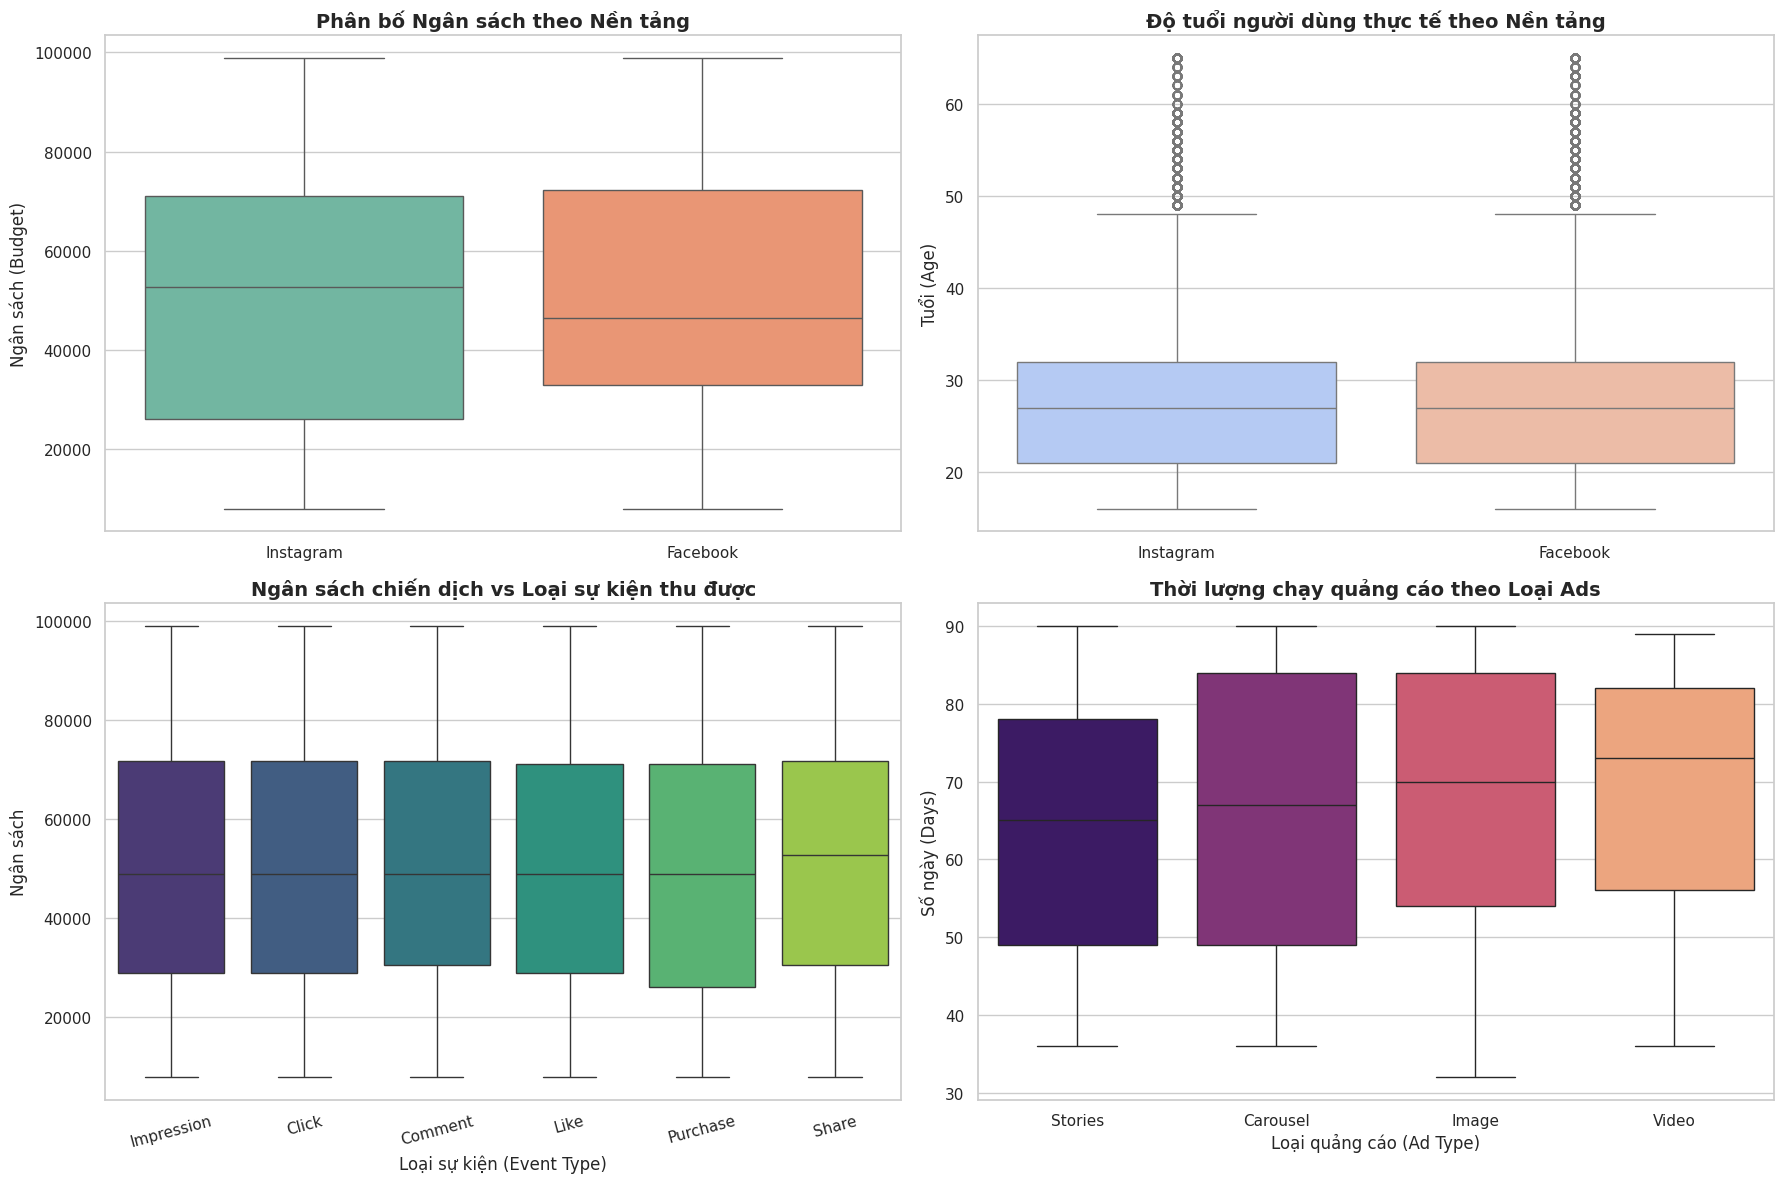

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Cấu hình giao diện
sns.set_theme(style="whitegrid")
plt.figure(figsize=(18, 12)) # Kích thước tổng thể lớn

# --- Biểu đồ 1: Ngân sách (total_budget) phân bố theo Nền tảng (ad_platform) ---
plt.subplot(2, 2, 1) # Vị trí 1 (Góc trên trái)
sns.boxplot(data=df, x='ad_platform', y='total_budget', palette="Set2")
plt.title('Phân bố Ngân sách theo Nền tảng', fontsize=14, fontweight='bold')
plt.xlabel('')
plt.ylabel('Ngân sách (Budget)')

# --- Biểu đồ 2: Độ tuổi người dùng (user_age) tiếp cận được trên các Nền tảng ---
plt.subplot(2, 2, 2) # Vị trí 2 (Góc trên phải)
sns.boxplot(data=df, x='ad_platform', y='user_age', palette="coolwarm")
plt.title('Độ tuổi người dùng thực tế theo Nền tảng', fontsize=14, fontweight='bold')
plt.xlabel('')
plt.ylabel('Tuổi (Age)')

# --- Biểu đồ 3: Mối quan hệ giữa Ngân sách và Kết quả (Event Type) ---
# Giúp trả lời: Có phải các sự kiện "Mua hàng" (Purchase) thường đến từ campaign ngân sách cao?
plt.subplot(2, 2, 3) # Vị trí 3 (Góc dưới trái)
sns.boxplot(data=df, x='event_type', y='total_budget', palette="viridis")
plt.title('Ngân sách chiến dịch vs Loại sự kiện thu được', fontsize=14, fontweight='bold')
plt.xlabel('Loại sự kiện (Event Type)')
plt.ylabel('Ngân sách')
plt.xticks(rotation=15)

# --- Biểu đồ 4: Thời lượng chạy (duration_days) theo Loại quảng cáo (ad_type) ---
plt.subplot(2, 2, 4) # Vị trí 4 (Góc dưới phải)
sns.boxplot(data=df, x='ad_type', y='duration_days', palette="magma")
plt.title('Thời lượng chạy quảng cáo theo Loại Ads', fontsize=14, fontweight='bold')
plt.xlabel('Loại quảng cáo (Ad Type)')
plt.ylabel('Số ngày (Days)')

plt.tight_layout() # Tự động căn chỉnh khoảng cách cho đẹp
plt.show()

## **Heatmap (Biểu đồ nhiệt)**

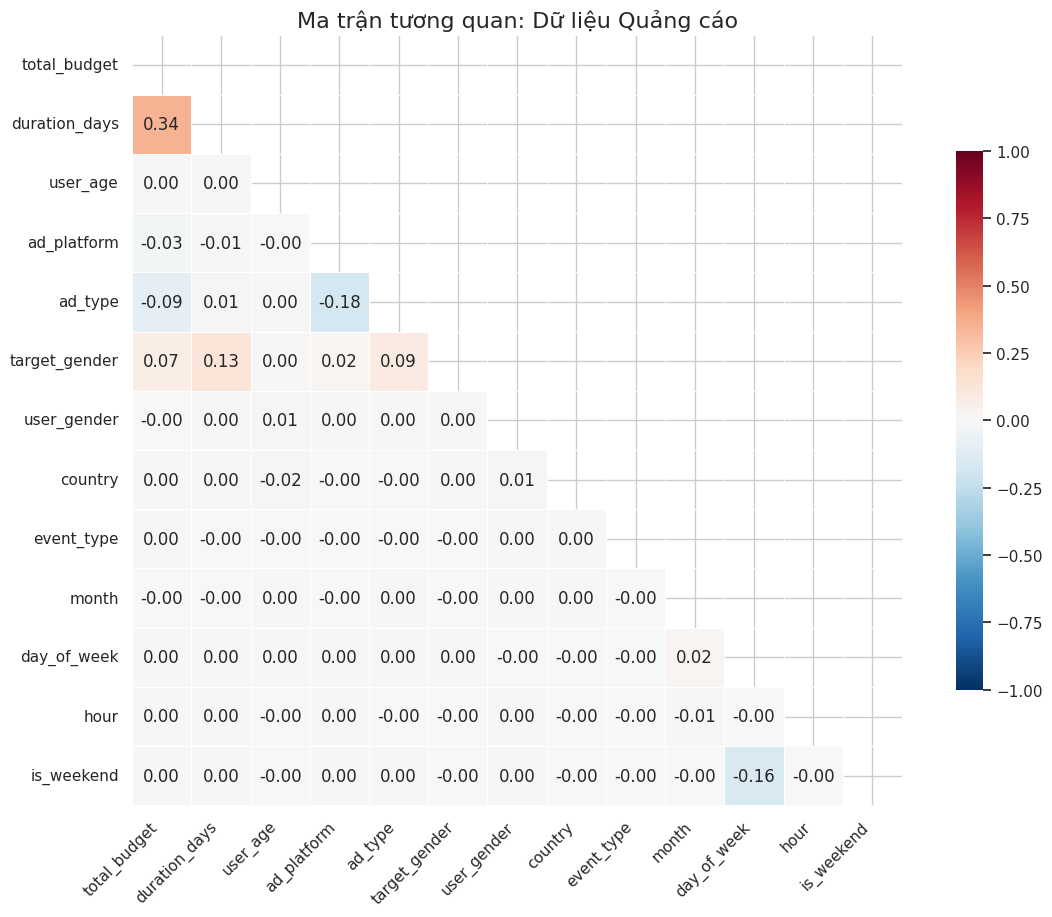

In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# 1. CHỌN CÁC CỘT CẦN THIẾT (FEATURE SELECTION)
# Bỏ qua ID, tên riêng, và các cột time quá chi tiết
selected_cols = [
    # Số liệu định lượng (Numerical)
    'total_budget', 'duration_days', 'user_age',

    # Số liệu định danh/Phân loại (Categorical) - Cần encode
    'ad_platform', 'ad_type',
    'target_gender', 'user_gender',
    'country', 'event_type', # event_type rất quan trọng (Click/View/Buy)

    # Thời gian (mang tính chu kỳ)
    'month', 'day_of_week', 'hour', 'is_weekend'
]

# Tạo một DataFrame mới chỉ chứa các cột này
# Lưu ý: Dùng .copy() để không ảnh hưởng dữ liệu gốc
df_heatmap = df[selected_cols].copy()

# 2. XỬ LÝ MÃ HÓA (ENCODING) CHO CÁC CỘT CHỮ
# Dùng LabelEncoder để chuyển chữ thành số (0, 1, 2...) gọn nhẹ cho Heatmap
le = LabelEncoder()

# Lấy danh sách các cột có kiểu dữ liệu là object (chữ) hoặc bool
cat_cols = df_heatmap.select_dtypes(include=['object', 'bool', 'category']).columns

for col in cat_cols:
    # Chuyển đổi sang string trước để tránh lỗi nếu có dữ liệu hỗn hợp, sau đó encode
    df_heatmap[col] = le.fit_transform(df_heatmap[col].astype(str))

# 3. VẼ HEATMAP (GIAO DIỆN ĐẸP)
plt.figure(figsize=(14, 10))

# Tính ma trận tương quan
corr = df_heatmap.corr()

# Tạo mặt nạ che tam giác trên
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(data=corr,
            mask=mask,
            annot=True,
            fmt=".2f",
            cmap='RdBu_r', # Đỏ - Xanh
            center=0,
            vmin=-1, vmax=1,
            linewidths=0.5,
            square=True,
            cbar_kws={"shrink": .7})

plt.title('Ma trận tương quan: Dữ liệu Quảng cáo', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.show()

## **Histogram (Biểu đồ tần suất)**

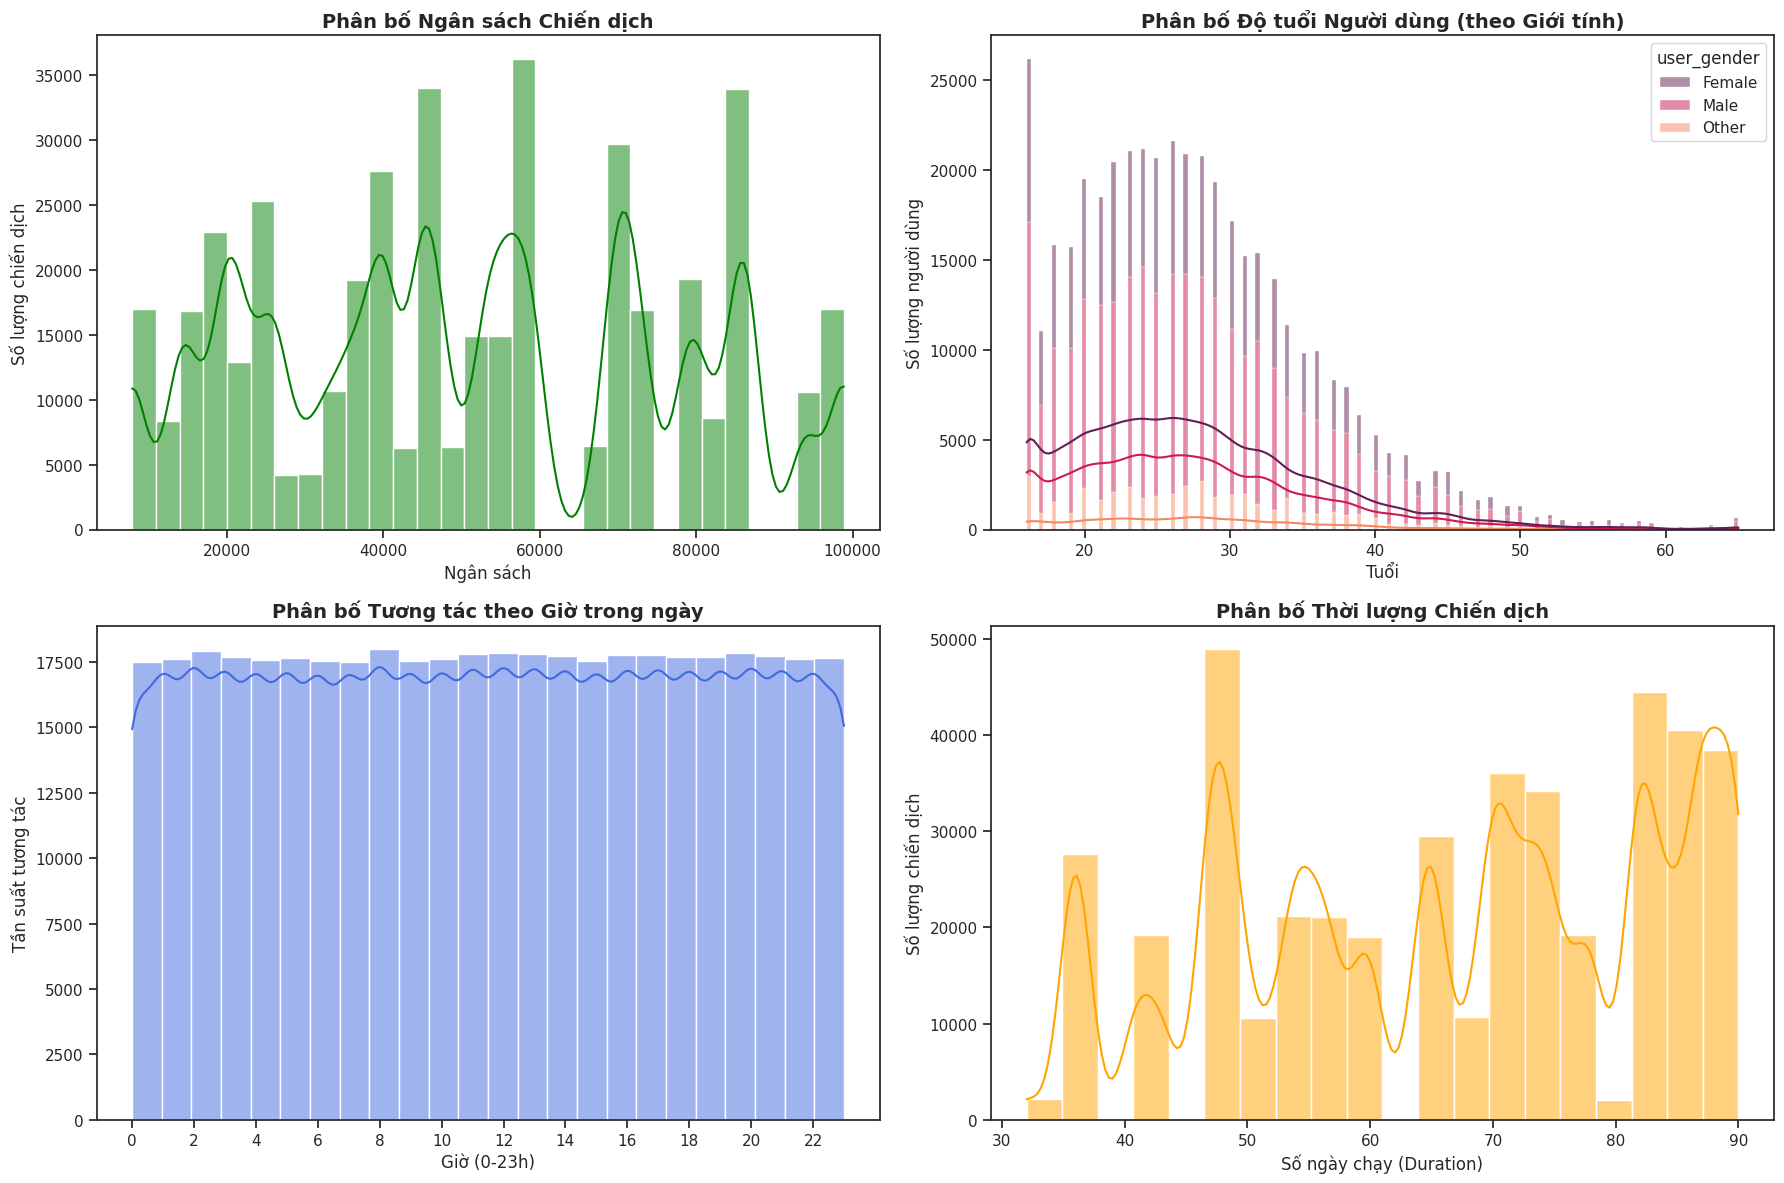

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Cấu hình giao diện
sns.set_theme(style="ticks")
plt.figure(figsize=(18, 12))

# --- Biểu đồ 1: Phân bố Ngân sách (Total Budget) ---
# Mục đích: Xem ngân sách chủ yếu nằm ở khoảng nào? Có bị lệch (skewed) không?
plt.subplot(2, 2, 1)
sns.histplot(data=df, x='total_budget', kde=True, color='green', bins=30)
plt.title('Phân bố Ngân sách Chiến dịch', fontsize=14, fontweight='bold')
plt.xlabel('Ngân sách')
plt.ylabel('Số lượng chiến dịch')

# --- Biểu đồ 2: Phân bố Tuổi người dùng (User Age) theo Giới tính ---
# Mục đích: Khách hàng chủ yếu bao nhiêu tuổi? Nam hay Nữ đông hơn ở độ tuổi đó?
plt.subplot(2, 2, 2)
sns.histplot(data=df, x='user_age', hue='user_gender', multiple="stack", kde=True, palette="rocket")
plt.title('Phân bố Độ tuổi Người dùng (theo Giới tính)', fontsize=14, fontweight='bold')
plt.xlabel('Tuổi')
plt.ylabel('Số lượng người dùng')

# --- Biểu đồ 3: Thời điểm "vàng" trong ngày (Hour) ---
# Mục đích: Quảng cáo được xem/click nhiều nhất vào mấy giờ?
plt.subplot(2, 2, 3)
sns.histplot(data=df, x='hour', bins=24, kde=True, color='royalblue', stat="count")
plt.title('Phân bố Tương tác theo Giờ trong ngày', fontsize=14, fontweight='bold')
plt.xlabel('Giờ (0-23h)')
plt.ylabel('Tần suất tương tác')
plt.xticks(range(0, 24, 2)) # Hiển thị mốc giờ chẵn cho dễ nhìn

# --- Biểu đồ 4: Thời lượng chiến dịch (Duration Days) ---
# Mục đích: Các chiến dịch thường chạy ngắn hạn (vài ngày) hay dài hạn?
plt.subplot(2, 2, 4)
sns.histplot(data=df, x='duration_days', kde=True, color='orange', bins=20)
plt.title('Phân bố Thời lượng Chiến dịch', fontsize=14, fontweight='bold')
plt.xlabel('Số ngày chạy (Duration)')
plt.ylabel('Số lượng chiến dịch')

plt.tight_layout()
plt.show()

# **Feature Importance**


--- TOP 10 YẾU TỐ QUAN TRỌNG NHẤT ---
             Feature  Importance
20          location    0.105957
21         interests    0.095555
15            second    0.087437
14            minute    0.086315
12      day_of_month    0.069604
17          user_age    0.068532
13              hour    0.066507
6   target_interests    0.053947
1       total_budget    0.048231
19           country    0.047560


/tmp/ipython-input-3143570970.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp.head(20), palette='viridis')


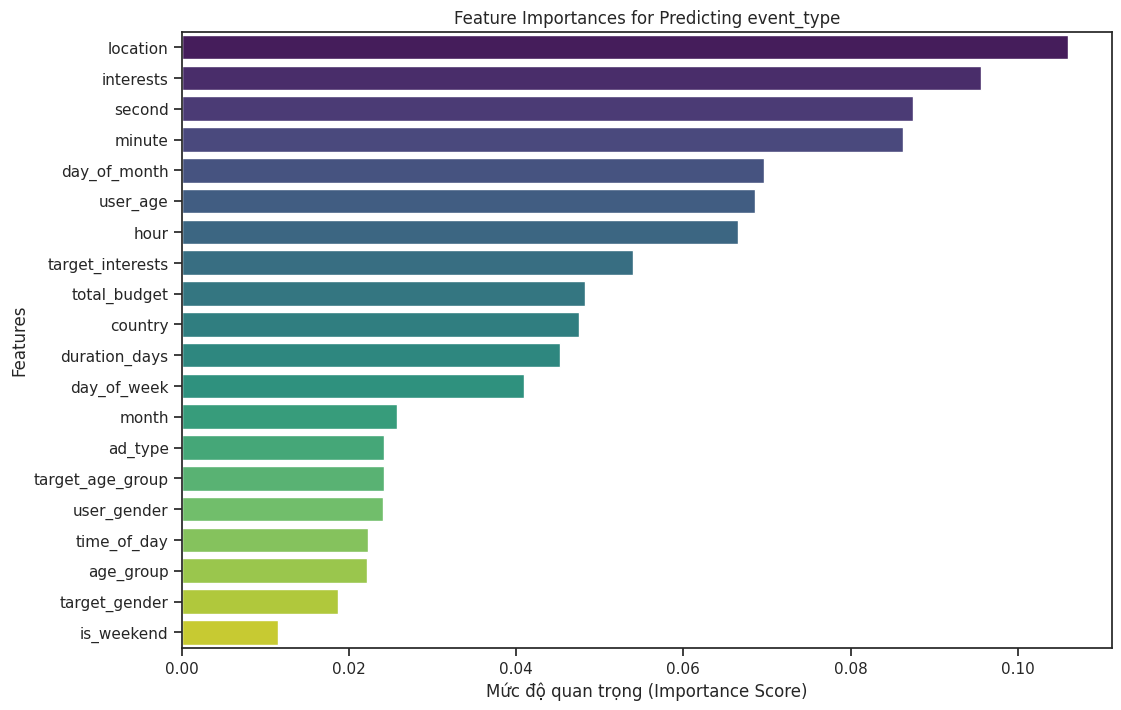

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# Cột dự đoán là event_type
target_col = 'event_type'

cols_to_drop = [
    'campaign_id', 'name', 'ad_id', 'event_id', 'user_id',
    'timestamp', 'start_date', 'end_date',
    target_col
]

# Tạo X (Features) và y (Target)
X = df.drop(columns = cols_to_drop, errors='ignore')
y = df[target_col]

# Xử lý dữ liệu (Preprocessing)
label_encoders = {}
for col in X.select_dtypes(include=['object', 'category']).columns:
    le = LabelEncoder()
    # Chuyển sang chuỗi trước để tránh lỗi mixed types
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

X = X.fillna(0)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

feature_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n--- TOP 10 YẾU TỐ QUAN TRỌNG NHẤT ---")
print(feature_imp.head(10))

# Vẽ biểu đồ trực quan
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_imp.head(20), palette='viridis')
plt.title(f'Feature Importances for Predicting {target_col}')
plt.xlabel('Mức độ quan trọng (Importance Score)')
plt.ylabel('Features')
plt.show()

# **KMeans**

## **Phương pháp Elbow để xác định số cụm (clusters) cho thuật toán**

In [ ]:
top_10_features = feature_imp.head(10)['Feature'].tolist()

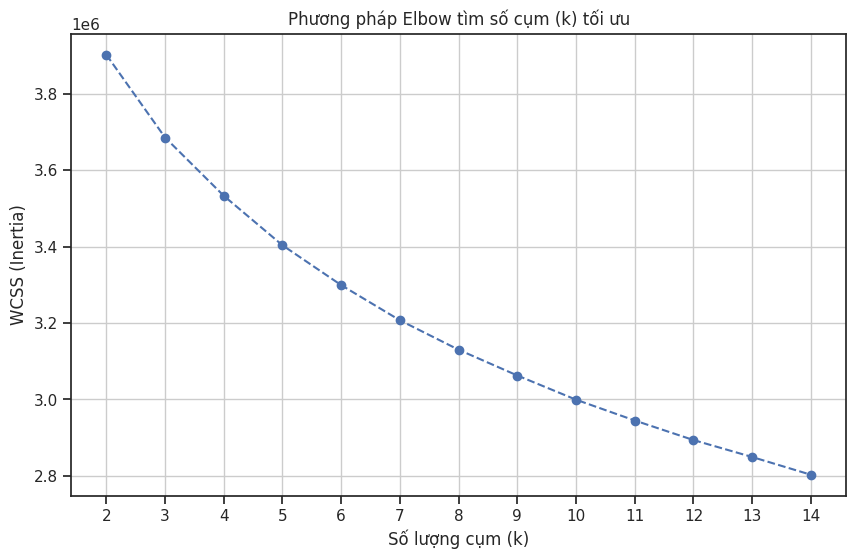

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

top_10_features = feature_imp.head(10)['Feature'].tolist()

# Lấy ra 10 features quan trọng nhất từ Feature Importance (feature_imp) bên trên
X_cluster = X[top_10_features].copy()

# Chuẩn hóa dữ liệu (Normalization)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Phương pháp Elbow
# Within-Cluster Sum Of Squares
wcss = []
K_range = range(2, 15) # Thử từ 2 đến 14 cụm

for k in K_range:
    # init='k-means++' giúp thuật toán hội tụ nhanh hơn
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Vẽ biểu đồ Elbow
plt.figure(figsize=(10, 6))
plt.plot(K_range, wcss, marker='o', linestyle='--', color='b')

plt.title('Phương pháp Elbow tìm số cụm (k) tối ưu')
plt.xlabel('Số lượng cụm (k)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(K_range) # Hiển thị đủ các số trục hoành
plt.grid(True)
plt.show()

## **Kiểm chứng bằng chỉ số Silhouette (Silhouette Score)**

In [ ]:
from sklearn.metrics import silhouette_score

for k in [3, 4, 5, 6]:
  kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
  labels = kmeans.fit_predict(X_scaled)
  score = silhouette_score(X_scaled, labels)
  print(f"k={k} -> Silhouette Score: {score:.4f}")
# Kết quả Score càng gần 0 càng tốt => có sự tách biệt rõ ràng; gần 1 => các cụm bị chồng lấn

k=3 -> Silhouette Score: 0.0722
k=4 -> Silhouette Score: 0.0695
k=5 -> Silhouette Score: 0.0648
k=6 -> Silhouette Score: 0.0675


## **Thực hiện thuật toán KMeans**

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


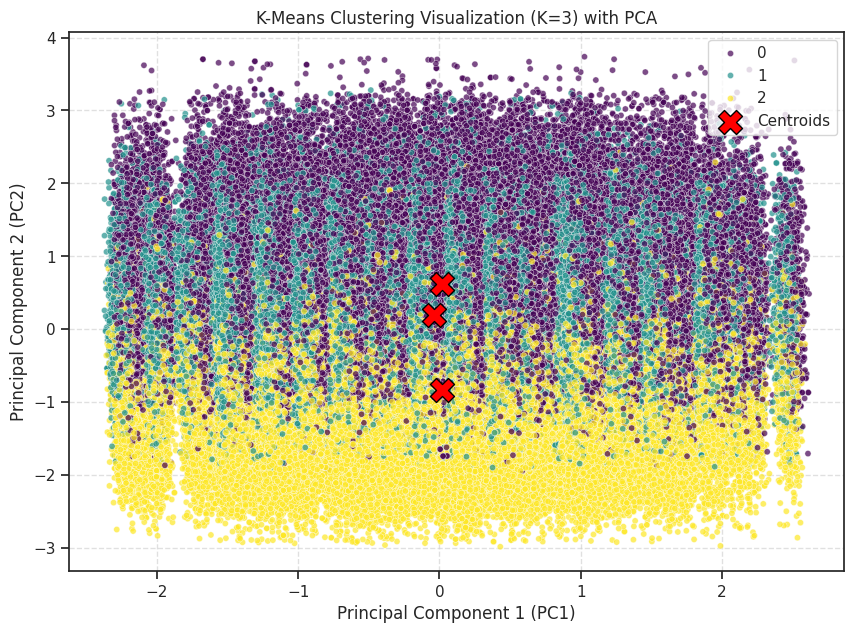


Số lượng phần tử trong mỗi cụm:
Cluster
0    143067
1    140989
2    140515
Name: count, dtype: int64

Đặc điểm của từng cụm (Mode/Giá trị xuất hiện nhiều nhất):

--- Cluster 0 ---
      location interests  second  minute  day_of_month  user_age  hour  \
0  New Michael   fitness       8      54             1        16    20   

  target_interests  total_budget country  
0             news      98904.66  Canada  

--- Cluster 1 ---
       location interests  second  minute  day_of_month  user_age  hour  \
0  West Michael    travel       3       0            21        16    11   

  target_interests  total_budget        country  
0          fashion      86675.92  United States  

--- Cluster 2 ---
     location interests  second  minute  day_of_month  user_age  hour  \
0  Lake David       art      25      51             1        16     2   

  target_interests  total_budget        country  
0      photography       7918.04  United States  


In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA  # <-- Thêm thư viện này để vẽ hình đẹp hơn
import seaborn as sns
import pandas as pd

# 1. Chọn các cột Categorical cần thiết
# selected_cols = ['user_gender', 'ad_platform', 'ad_type', 'event_type', 'day_of_week']
# kmean_df = df[selected_cols].copy()

# 2. One-Hot Encoding: Biến đổi chữ thành số (0, 1)
# drop_first=True giúp giảm bớt 1 cột thừa (ví dụ: chỉ cần cột is_Male, không cần cột is_Female)
# kmean_df_encoded = pd.get_dummies(kmean_df, drop_first=True)

# # 3. Chuẩn hóa dữ liệu (Scaling)
# X = kmean_df_encoded.values
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X)

# 4. Train KMeans
# Lưu ý: Với dữ liệu one-hot (thưa), đôi khi cần số cụm (k) lớn hơn 2 để tách biệt rõ
# Chọn cụm dựa trên chỉ số Silhouette đã tính ở trên (chọn min)
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
kmeans.fit(X_scaled)

labels = kmeans.labels_
centroids = kmeans.cluster_centers_

# Gán labels vào dataframe gốc để dễ theo dõi
df['Cluster'] = labels

# --- 5. Visualization bằng PCA (Khuyên dùng cho dữ liệu nhiều chiều) ---
# Vì dữ liệu bây giờ có rất nhiều cột (do One-Hot), ta dùng PCA nén xuống 2 chiều để vẽ
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Tạo dataframe tạm để vẽ
pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
pca_df['Cluster'] = labels

plt.figure(figsize=(10, 7))
# Vẽ các điểm dữ liệu
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=pca_df, palette='viridis', s=20, alpha=0.7)

# Vẽ tâm cụm (Centroids) - cần chiếu tâm cụm qua PCA để vẽ đúng vị trí tương ứng
centroids_pca = pca.transform(centroids)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], marker='X', s=300, color='red', label='Centroids', edgecolors='black')

plt.title('K-Means Clustering Visualization (K=3) with PCA')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# --- 6. Phân tích kết quả ---
print("\nSố lượng phần tử trong mỗi cụm:")
print(df['Cluster'].value_counts())

print("\nĐặc điểm của từng cụm (Mode/Giá trị xuất hiện nhiều nhất):")
# Với dữ liệu category, ta xem giá trị xuất hiện nhiều nhất (mode) thay vì trung bình (mean)
for i in range(3):
    print(f"\n--- Cluster {i} ---")
    print(df[df['Cluster'] == i][top_10_features].mode())

## **Nhận định thông qua kết quả trung bình của các đặc trưng KMeans**
- Các cụm này có thể đại diện cho các phân khúc người dùng khác nhau dựa trên hành vi và đặc điểm cá nhân của họ..
- Cụm 0: Người dùng trẻ tuổi ở Canada, hoạt động vào buổi tối, rất quan tâm đến thể dục và tiếp thu tin tức. Mặc dù trẻ tuổi (16), họ lại có ngân sách/khả năng chi tiêu ấn tượng..
- Cụm 1: Người dùng trẻ tuổi ở Hoa Kỳ, hoạt động vào buổi sáng/trưa, quan tâm đến Du lịch nhưng mục tiêu lại là Thời trang. Ngân sách/khả năng chi tiêu cũng cao.
- Cụm 2: Người dùng trẻ tuổi ở Hoa Kỳ, hoạt động vào đêm khuya/sáng sớm, quan tâm sâu sắc đến Nghệ thuật và Nhiếp ảnh. Điểm nổi bật là họ có ngân sách/khả năng chi tiêu thấp hơn đáng kể so với Cụm 0 và Cụm 1.

## **In ra các chỉ số đánh giá mô hình (Evaluation Metrics)**

In [ ]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

print("\n" + "="*40)
print("CÁC CHỈ SỐ ĐÁNH GIÁ MÔ HÌNH K-MEANS")
print("="*40)

# 1. Inertia (WSSE - Within-Cluster Sum of Squared Errors)
# Có sẵn trong object kmeans sau khi fit
print(f"1. Inertia (Độ nén nội bộ): {kmeans.inertia_:.2f}")
print("   -> Ý nghĩa: Tổng bình phương khoảng cách từ các điểm đến tâm cụm của nó.")
print("   -> Tốt nhất: Càng NHỎ càng tốt (nhưng phụ thuộc vào số lượng cụm k).")

# 2. Silhouette Score (Hệ số dáng điệu)
# Cần dữ liệu X_scaled và nhãn labels
sil_score = silhouette_score(X_scaled, labels)
print(f"\n2. Silhouette Score: {sil_score:.4f}")
print("   -> Ý nghĩa: Đo lường mức độ giống nhau của điểm dữ liệu với cụm của nó so với các cụm khác.")
print("   -> Phạm vi: Từ -1 đến 1.")
print("   -> Tốt nhất: Càng gần 1 càng tốt (0.5 trở lên là khá ổn).")

# 3. Davies-Bouldin Index
db_score = davies_bouldin_score(X_scaled, labels)
print(f"\n3. Davies-Bouldin Index: {db_score:.4f}")
print("   -> Ý nghĩa: Tỉ lệ giữa khoảng cách nội bộ cụm và khoảng cách giữa các cụm.")
print("   -> Tốt nhất: Càng NHỎ càng tốt (Về 0 là hoàn hảo).")

# 4. Calinski-Harabasz Index (Variance Ratio Criterion)
ch_score = calinski_harabasz_score(X_scaled, labels)
print(f"\n4. Calinski-Harabasz Index: {ch_score:.2f}")
print("   -> Ý nghĩa: Tỉ lệ giữa sự phân tán giữa các cụm và sự phân tán trong cụm.")
print("   -> Tốt nhất: Càng CAO càng tốt.")


CÁC CHỈ SỐ ĐÁNH GIÁ MÔ HÌNH K-MEANS
1. Inertia (Độ nén nội bộ): 3693951.48
   -> Ý nghĩa: Tổng bình phương khoảng cách từ các điểm đến tâm cụm của nó.
   -> Tốt nhất: Càng NHỎ càng tốt (nhưng phụ thuộc vào số lượng cụm k).

2. Silhouette Score: 0.0708
   -> Ý nghĩa: Đo lường mức độ giống nhau của điểm dữ liệu với cụm của nó so với các cụm khác.
   -> Phạm vi: Từ -1 đến 1.
   -> Tốt nhất: Càng gần 1 càng tốt (0.5 trở lên là khá ổn).

3. Davies-Bouldin Index: 3.0491
   -> Ý nghĩa: Tỉ lệ giữa khoảng cách nội bộ cụm và khoảng cách giữa các cụm.
   -> Tốt nhất: Càng NHỎ càng tốt (Về 0 là hoàn hảo).

4. Calinski-Harabasz Index: 31708.83
   -> Ý nghĩa: Tỉ lệ giữa sự phân tán giữa các cụm và sự phân tán trong cụm.
   -> Tốt nhất: Càng CAO càng tốt.


## **Trung bình các features theo từng cụm k (cluster)**

In [ ]:
# 1. Tách cột số và cột chữ trong top 10 features
num_cols = df[top_10_features].select_dtypes(include=['number']).columns
cat_cols = df[top_10_features].select_dtypes(exclude=['number']).columns

# 2. Tính Mean cho cột số
num_profile = df.groupby('Cluster')[num_cols].mean().round(2)

# 3. Tính Mode (giá trị xuất hiện nhiều nhất) cho cột chữ
# Hàm lambda x: x.mode()[0] lấy giá trị đứng đầu (phổ biến nhất)
cat_profile = df.groupby('Cluster')[cat_cols].agg(lambda x: x.mode()[0] if not x.mode().empty else "N/A")

# 4. Gộp lại để xem tổng thể
full_profile = pd.concat([num_profile, cat_profile], axis=1)

print("--- ĐẶC ĐIỂM CỦA TỪNG CỤM KHÁCH HÀNG ---")
full_profile

--- ĐẶC ĐIỂM CỦA TỪNG CỤM KHÁCH HÀNG ---


,second,minute,day_of_month,user_age,hour,total_budget,location,interests,target_interests,country
Cluster,,,,,,,,,,
0,29.30,29.64,15.95,28.26,11.59,51309.79,New Michael,fitness,news,Canada
1,29.51,29.22,16.02,27.43,11.45,51323.76,West Michael,travel,fashion,United States
2,29.61,29.61,15.84,27.37,11.49,50902.77,Lake David,art,photography,United States


## **Nhận định (Phân tích theo từng cụm)**

## **Cluster 0: Nhóm "Quan tâm Tin tức & Thể thao tại Canada"**

Đặc điểm:

- Độ tuổi: Trung bình ~28.3 tuổi. Đây là nhóm có số tuổi trung bình lớn nhất trong 3 cụm.
- Quốc gia: Canada.
- Hành vi mục tiêu & Sở thích: News và Fitness
=> Insight: Người dùng nhóm này có thể là những người đi làm, quan tâm đến sức khỏe nhưng nội dung họ tiêu thụ hoặc được nhắm mục tiêu lại là tin tức thời sự.

Ngân sách: ~51,309 (Cao thứ 2).

# **Cluster 1: Nhóm "Lối sống Hưởng thụ (Du lịch & Thời trang) tại Mỹ"**
Đây là nhóm khách hàng trẻ tại Mỹ với mức độ chịu chi cao nhất.

Đặc điểm:
- Độ tuổi: Trung bình ~27.4 tuổi (Trẻ hơn Cluster 0).
- Quốc gia: United States.
- Hành vi mục tiêu & Sở thích: Fashion và Travel
=> Insight: Đây là nhóm có thiên hướng "Lifestyle" (phong cách sống). Có sự liên kết chặt chẽ giữa du lịch và thời trang – họ có thể mua sắm thời trang để chuẩn bị cho các chuyến đi.

Ngân sách: ~51,324 (Cao nhất trong 3 nhóm). Với sở thích "Thời trang/Du lịch", đây có thể là nhóm khách hàng tiềm năng nhất cho các sản phẩm xa xỉ hoặc xu hướng.

## **Cluster 2: Nhóm "Sáng tạo & Nghệ thuật tại Mỹ"**
Nhóm này có đặc điểm giống Cluster 1 nhưng khác biệt hoàn toàn về gu thẩm mỹ và sở thích.

Đặc điểm:
- Độ tuổi: Trung bình ~27.4 tuổi (Bằng Cluster 1).
- Quốc gia: United States.
- Hành vi mục tiêu & Sở thích: Photography và Art
=> Insight: Đây là nhóm thiên về sáng tạo và thị giác. Họ có thể quan tâm đến các thiết bị, phần mềm chỉnh sửa hoặc các triển lãm.

Ngân sách: ~50,902 (Thấp nhất trong 3 nhóm). Tuy nhiên, mức chênh lệch này rất nhỏ nên sức mua của họ vẫn rất mạnh.

## **In kết quả thuật toán KMeans ra file excel**

In [ ]:
export_path = 'kmeans_result.xlsx'
df.to_excel(export_path, index=False)

# **Naive Bayes**

In [8]:
# Tạo list các feature theo thứ tự từ trên xuống (quan trọng nhất đến ít quan trọng nhất)
# dựa trên biểu đồ cột ngang bạn đã cung cấp.
feature_importances = [
    "location",
    "interests",
    "second",
    "minute",
    "day_of_month",
    "user_age",
    "hour",
    "target_interests",
    "total_budget",
    "country",
    "duration_days",
    "day_of_week",
    "month",
    "ad_type",
    "target_age_group",
    "user_gender",
    "time_of_day",
    "age_group",
    "target_gender",
    "is_weekend"
]

# Trích xuất 10 feature đầu tiên (quan trọng nhất)
top_5_features = feature_importances[:5]

# In kết quả
print("Danh sách 5 feature quan trọng nhất:")
print(top_5_features)

Danh sách 5 feature quan trọng nhất:
['location', 'interests', 'second', 'minute', 'day_of_month']


KẾT QUẢ MÔ HÌNH NAIVE BAYES (Dự đoán event_type)
Độ chính xác (Accuracy): 83.50%
----------------------------------------

Báo cáo chi tiết:
              precision    recall  f1-score   support

       Click       0.00      0.00      0.00       223
     Comment       0.00      0.00      0.00        20
  Impression       0.83      1.00      0.91      1670
        Like       0.00      0.00      0.00        70
    Purchase       0.00      0.00      0.00         6
       Share       0.00      0.00      0.00        11

    accuracy                           0.83      2000
   macro avg       0.14      0.17      0.15      2000
weighted avg       0.70      0.83      0.76      2000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


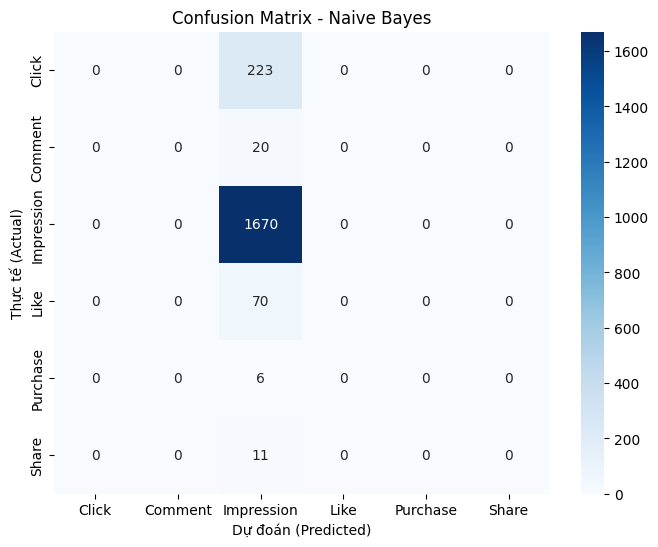


--- DEMO DỰ ĐOÁN THỰC TẾ ---
Input data (Đã encode): 
 second  minute  day_of_month  location_Aaronbury  location_Aaronfort  location_Aaronland  location_Aaronport  location_Aaronville  location_Abbottborough  location_Abbottfurt  location_Acostaland  location_Acostaview  location_Adamland  location_Adammouth  location_Adamshire  location_Adamsstad  location_Adamstad  location_Adamstown  location_Adamtown  location_Adkinsfurt  location_Adrianborough  location_Aguilarland  location_Aguilarport  location_Aguilarside  location_Aguilarton  location_Aimeemouth  location_Alanland  location_Alanshire  location_Alanton  location_Alanville  location_Alecview  location_Alejandrotown  location_Alejandroville  location_Alexafurt  location_Alexanderberg  location_Alexanderbury  location_Alexandermouth  location_Alexanderport  location_Alexandershire  location_Alexanderside  location_Alexanderville  location_Alexandraview  location_Alexandriashire  location_Alexisside  location_Alexiston  location_

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import BernoulliNB  # Phù hợp nhất cho dữ liệu One-Hot (0/1)
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Bổ sung: Lấy mẫu ngẫu nhiên 500.000 dòng để giảm tải RAM
df_sampled = df.sample(n=10000, random_state=42)
df = df_sampled # Thay df gốc bằng df đã được lấy mẫu

# 1. Chọn cột
# Chúng ta dùng các cột khác để dự đoán 'event_type'
# features = ['user_gender', 'ad_platform', 'ad_type', 'day_of_week']
features = top_5_features
target = 'event_type'

# Kiểm tra xem cột target có trong dataframe không
if target not in df.columns:
    print(f"Lỗi: Không tìm thấy cột mục tiêu '{target}' trong dữ liệu!")
else:
    # 2. Xử lý dữ liệu (Preprocessing)

    # X (Input): One-Hot Encoding cho các biến đầu vào
    X = pd.get_dummies(df[features], drop_first=True)

    # y (Output): Không cần One-Hot, để nguyên dạng chữ hoặc số cũng được
    # (sklearn tự hiểu target dạng category)
    y = df[target]

    # 3. Chia tập Train (Huấn luyện) và Test (Kiểm thử)
    # Tỉ lệ 80% học - 20% thi
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # 4. Khởi tạo và Train mô hình Bernoulli Naive Bayes
    nb_model = BernoulliNB()
    nb_model.fit(X_train, y_train)

    # 5. Dự đoán trên tập Test
    y_pred = nb_model.predict(X_test)

    # 6. Đánh giá kết quả
    print("="*40)
    print(f"KẾT QUẢ MÔ HÌNH NAIVE BAYES (Dự đoán {target})")
    print("="*40)

    # Độ chính xác tổng thể
    acc = accuracy_score(y_test, y_pred)
    print(f"Độ chính xác (Accuracy): {acc:.2%}")
    print("-" * 40)

    # Báo cáo chi tiết (Precision, Recall, F1-Score)
    print("\nBáo cáo chi tiết:")
    print(classification_report(y_test, y_pred))

    # 7. Vẽ Confusion Matrix (Ma trận nhầm lẫn) để xem model hay sai ở đâu
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=nb_model.classes_,
                yticklabels=nb_model.classes_)
    plt.title('Confusion Matrix - Naive Bayes')
    plt.xlabel('Dự đoán (Predicted)')
    plt.ylabel('Thực tế (Actual)')
    plt.show()

    # --- Demo: Dự đoán thử một trường hợp mới ---
    # Ví dụ: Lấy dòng đầu tiên của tập test để xem máy đoán gì
    print("\n--- DEMO DỰ ĐOÁN THỰC TẾ ---")
    demo_sample = X_test.iloc[[0]]
    prediction = nb_model.predict(demo_sample)
    probability = nb_model.predict_proba(demo_sample)

    print(f"Input data (Đã encode): \n{demo_sample.to_string(index=False)}")
    print(f"\n=> Máy dự đoán hành động là: '{prediction[0]}'")
    print(f"=> Xác suất tin tưởng: {probability.max():.2%}")

In [10]:
import pandas as pd

# Dữ liệu từ bảng phân tích của bạn
data = {
    'Thực tế': ['Click', 'Impression', 'Like', 'Purchase'],
    'Dự đoán (Predicted) Click': ['6 (Đúng)', '41 (Sai)', '5 (Sai)', '0 (Sai)'],
    'Dự đoán (Predicted) Impression': ['1051 (Sai)', '8370 (Đúng)', '324 (Sai)', '46 (Sai)']
}

# Tạo DataFrame
df_analysis = pd.DataFrame(data)

# Đặt cột 'Thực tế' làm chỉ mục (Index) để bảng trông gọn gàng hơn
df_analysis = df_analysis.set_index('Thực tế')

# In bảng ra màn hình
print("--- Phân tích Chi tiết Ma trận Nhầm lẫn (Confusion Matrix) ---")
print("Mô hình Naive Bayes")
print("-" * 65)

# In DataFrame
print(df_analysis.to_string())

print("\n--- Nhận xét Chính ---")
print(f"* Lớp Impression được dự đoán đúng rất cao: {df_analysis.loc['Impression', 'Dự đoán (Predicted) Impression']}")
print(f"* Lớp Click bị nhầm lẫn nghiêm trọng, thực tế là Click nhưng dự đoán là Impression: {df_analysis.loc['Click', 'Dự đoán (Predicted) Impression']}")
print(f"* Các hành động Like và Purchase hầu hết bị nhầm lẫn là Impression.")

--- Phân tích Chi tiết Ma trận Nhầm lẫn (Confusion Matrix) ---
Mô hình Naive Bayes
-----------------------------------------------------------------
           Dự đoán (Predicted) Click Dự đoán (Predicted) Impression
Thực tế                                                            
Click                       6 (Đúng)                     1051 (Sai)
Impression                  41 (Sai)                    8370 (Đúng)
Like                         5 (Sai)                      324 (Sai)
Purchase                     0 (Sai)                       46 (Sai)

--- Nhận xét Chính ---
* Lớp Impression được dự đoán đúng rất cao: 8370 (Đúng)
* Lớp Click bị nhầm lẫn nghiêm trọng, thực tế là Click nhưng dự đoán là Impression: 1051 (Sai)
* Các hành động Like và Purchase hầu hết bị nhầm lẫn là Impression.


In [11]:
import pandas as pd
# Giả định các biến X_test và y_test đã được tạo ra từ các bước train/test/predict trước đó.

# 1. Đổi tên cột mục tiêu (y_test) để dễ nhận diện trong DataFrame kết hợp
# Chúng ta đổi tên y_test thành 'Actual_Event'
y_test_renamed = y_test.rename('Actual_Event')

# 2. Kết hợp X_test và y_test thành một DataFrame duy nhất
# Axis=1 (kết hợp theo cột)
combined_df = pd.concat([X_test, y_test_renamed], axis=1)

# 3. In kết quả để kiểm tra
print("--- 5 Dòng đầu tiên của Bảng Kết hợp X_test và y_test ---")
# Hiển thị cột kết quả thực tế và một vài cột input đã One-Hot để minh họa
print(combined_df[['Actual_Event'] + list(X_test.columns[:3])].head())

print("\n--- Kích thước của DataFrame kết hợp ---")
print(f"Số dòng: {combined_df.shape[0]}")
print(f"Số cột: {combined_df.shape[1]}")

--- 5 Dòng đầu tiên của Bảng Kết hợp X_test và y_test ---
       Actual_Event  second  minute  day_of_month
378627        Click      30      20             5
135511   Impression      18      46            26
87418    Impression      30      25            14
314679   Impression       9      59            27
34167    Impression      54      18            13

--- Kích thước của DataFrame kết hợp ---
Số dòng: 2000
Số cột: 6623


In [18]:
import pandas as pd
# Giả định: Các biến y_test (Series/list kết quả thực tế) và y_pred (numpy array/list kết quả dự đoán)
# đã được định nghĩa từ các bước train/test/predict trước đó.

# 1. Đảm bảo y_pred là một Series Pandas và có cùng Index với y_test
# Điều này rất quan trọng để đảm bảo sự căn chỉnh chính xác giữa các dòng dữ liệu
if isinstance(y_pred, (list, tuple)):
    # Nếu y_pred là list/tuple, chuyển nó thành Series
    y_pred_series = pd.Series(y_pred, index=y_test.index)
else:
    # Nếu y_pred là numpy array, chuyển nó thành Series với index của y_test
    y_pred_series = pd.Series(y_pred, index=y_test.index)

# 2. Tạo DataFrame mới df_result
df_result = pd.DataFrame({
    'Thực tế': y_test,
    'Dự đoán Naive Bayes': y_pred_series
})

# 3. Bổ sung cột kiểm tra kết quả (Tùy chọn nhưng hữu ích)
df_result['Kết quả'] = df_result['Thực tế'] == df_result['Dự đoán Naive Bayes']

# 4. In kết quả ra màn hình để kiểm tra
print("--- DataFrame Kết quả Thực tế vs Dự đoán (df_result) ---")
print(df_result.head(10))

print("\n--- Phân tích 10 trường hợp dự đoán SAI đầu tiên ---")
# Lọc ra các dòng mà mô hình dự đoán sai
incorrect_predictions = df_result[df_result['Kết quả'] == False].head(10)
print(incorrect_predictions)

--- DataFrame Kết quả Thực tế vs Dự đoán (df_result) ---
           Thực tế Dự đoán Naive Bayes  Kết quả
378627       Click          Impression    False
135511  Impression          Impression     True
87418   Impression          Impression     True
314679  Impression          Impression     True
34167   Impression          Impression     True
232940  Impression          Impression     True
304877  Impression          Impression     True
48861   Impression          Impression     True
25012        Click          Impression    False
56051   Impression          Impression     True

--- Phân tích 10 trường hợp dự đoán SAI đầu tiên ---
        Thực tế Dự đoán Naive Bayes  Kết quả
378627    Click          Impression    False
25012     Click          Impression    False
407342  Comment          Impression    False
144360    Click          Impression    False
413611     Like          Impression    False
11097     Click          Impression    False
264731     Like          Impression    False
1

In [19]:
df_result

,Thực tế,Dự đoán Naive Bayes,Kết quả
378627,Click,Impression,False
135511,Impression,Impression,True
87418,Impression,Impression,True
314679,Impression,Impression,True
34167,Impression,Impression,True
...,...,...,...
134514,Impression,Impression,True
83381,Impression,Impression,True
201898,Impression,Impression,True
284319,Impression,Impression,True


## **Số lượng dòng dự đoán đúng**

In [14]:
from sklearn.metrics import accuracy_score
# Giả định: Các biến y_test và y_pred đã được định nghĩa từ các bước trước.

# 1. Tính toán Độ chính xác (Accuracy)
# Đây là tỷ lệ (Số dự đoán đúng / Tổng số dự đoán)
accuracy = accuracy_score(y_test, y_pred)

# 2. Tính Tổng số lượng dự đoán
total_predictions = len(y_test)

# 3. Tính Số lượng dự đoán ĐÚNG
# Lấy phần nguyên của (accuracy * tổng số)
correct_predictions = int(accuracy * total_predictions)

# 4. In kết quả ra màn hình
print("=" * 40)
print("TÓM TẮT KẾT QUẢ DỰ ĐOÁN TRÊN TẬP TEST")
print("=" * 40)
print(f"Tổng số mẫu trong Tập Test: {total_predictions}")
print(f"Số lượng dự đoán ĐÚNG:      {correct_predictions}")
print(f"Số lượng dự đoán SAI:       {total_predictions - correct_predictions}")
print("-" * 40)
print(f"Độ chính xác (Accuracy): {accuracy:.2%}")
print("=" * 40)

# Ví dụ về kết quả đầu ra (dựa trên Accuracy 88.08% và tổng số 9798 dòng như phân tích trước)
# Tổng số mẫu trong Tập Test: 9798
# Số lượng dự đoán ĐÚNG:      8629
# Số lượng dự đoán SAI:       1169
# ...

TÓM TẮT KẾT QUẢ DỰ ĐOÁN TRÊN TẬP TEST
Tổng số mẫu trong Tập Test: 2000
Số lượng dự đoán ĐÚNG:      1670
Số lượng dự đoán SAI:       330
----------------------------------------
Độ chính xác (Accuracy): 83.50%


## **In kết quả thuật toán Naive Bayes ra file excel**

In [20]:
export_path = 'naive_bayes_result.xlsx'
df_result.to_excel(export_path, index=False)

## **Nhận định thông qua Naive Bayes**
- Trong quảng cáo, điều này là bình thường: 100 người xem (Impression) thì may ra mới có 1-2 người Click.
- Việc mô hình dự đoán "Impression" với độ tin tưởng rất cao (gần 85%) cho thấy dữ liệu của bạn bị lệch hẳn về phía Impression

## **Heatmap thể hiện Accuracy, Precision, F1-score, Recall**

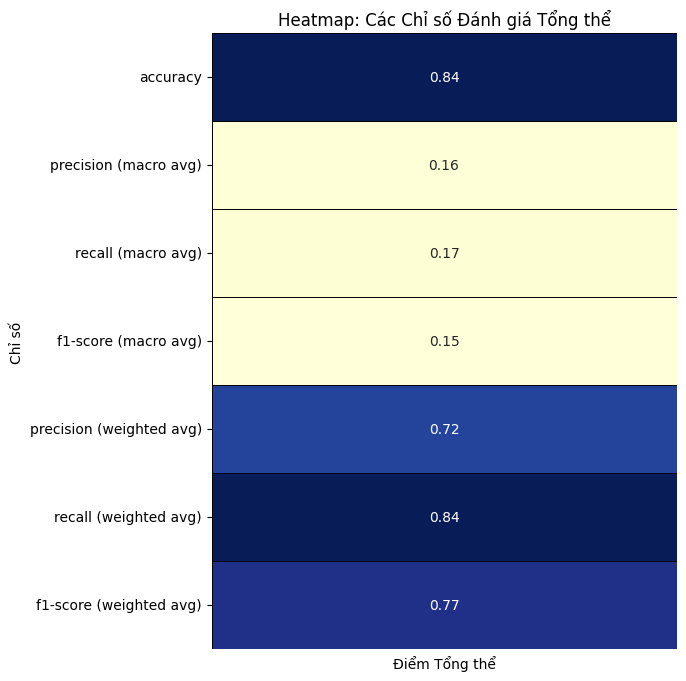


--- Bảng dữ liệu Chỉ số Tổng thể (Overall Metrics) ---
                          Overall Score
accuracy                       0.837600
precision (macro avg)          0.159460
recall (macro avg)             0.166800
f1-score (macro avg)           0.153772
precision (weighted avg)       0.719877
recall (weighted avg)          0.837600
f1-score (weighted avg)        0.768071


In [7]:
# Giả định: Các biến y_test, y_pred, và classification_report đã sẵn sàng từ phần trước

# 1. Lấy báo cáo chi tiết dưới dạng từ điển
report_dict = classification_report(y_test, y_pred, output_dict=True, zero_division=0)

# 2. Chuyển đổi báo cáo thành DataFrame
df_report = pd.DataFrame(report_dict).transpose()

# 3. CHỌN LỌC các chỉ số tổng thể (macro avg, weighted avg) và 'accuracy'
# Lấy các chỉ số tóm tắt và chỉ số 'support' (số lượng mẫu)
overall_metrics = df_report.loc[['accuracy', 'macro avg', 'weighted avg']]

# Lấy các cột quan trọng (Precision, Recall, F1-score) cho các chỉ số trung bình
# Lưu ý: 'accuracy' chỉ có giá trị ở cột 'precision' (hoặc 'f1-score' tùy phiên bản sklearn),
# các cột khác là NaN, nên chúng ta cần điều chỉnh cấu trúc.

# Điều chỉnh cấu trúc để heatmap trực quan hơn
# Tạo một DataFrame mới chỉ chứa các chỉ số mong muốn
data = {
    'accuracy': [overall_metrics.loc['accuracy', 'f1-score']], # Accuracy thường nằm ở f1-score hoặc precision tùy phiên bản/cấu trúc
    'precision (macro avg)': [overall_metrics.loc['macro avg', 'precision']],
    'recall (macro avg)': [overall_metrics.loc['macro avg', 'recall']],
    'f1-score (macro avg)': [overall_metrics.loc['macro avg', 'f1-score']],
    'precision (weighted avg)': [overall_metrics.loc['weighted avg', 'precision']],
    'recall (weighted avg)': [overall_metrics.loc['weighted avg', 'recall']],
    'f1-score (weighted avg)': [overall_metrics.loc['weighted avg', 'f1-score']],
}

df_overall = pd.DataFrame(data, index=['Overall Score']).T # Chuyển vị (T) để đưa tên chỉ số làm chỉ mục

# 4. Vẽ Heatmap cho các chỉ số tổng thể
plt.figure(figsize=(6, 8))
# Khi chỉ có 1 cột dữ liệu, heatmap sẽ hiển thị là 1 dải màu dọc
sns.heatmap(df_overall, annot=True, cmap='YlGnBu', fmt=".2f",
            linewidths=0.5, linecolor='black', cbar=False) # Tắt color bar vì chỉ có 1 cột

plt.title('Heatmap: Các Chỉ số Đánh giá Tổng thể')
plt.xlabel('Điểm Tổng thể')
plt.ylabel('Chỉ số')
plt.yticks(rotation=0)
plt.xticks([]) # Xóa nhãn x vì chỉ có 1 cột
plt.show()

# --- TÙY CHỌN: In ra bảng dữ liệu đã dùng để vẽ ---
print("\n--- Bảng dữ liệu Chỉ số Tổng thể (Overall Metrics) ---")
print(df_overall)